In [58]:
from __future__ import print_function, division
import sys,os
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
import pandas as pd

%matplotlib inline 

font = {
        'weight' : 'bold',
        'size'   : 16}
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('font', **font) 

figures_path = "../figs"
model = "EHM_Itensor" 
exec = "Phase_Diagram"
results = "../results"

U_max = 6.0
V_max = 4.0

U_min = -U_max
V_min = -V_max

N_Points = 80
L = 6

'''
        L = 6, N_Points = 80
'''

'\n        L = 6, N_Points = 80\n'

In [45]:
def load_density_density_results(L, U_vals, V_vals, N_Points):
    
    magnetization = np.zeros((N_Points, N_Points, L))
    charge_density = np.zeros((N_Points, N_Points, L))
    doublons = np.zeros((N_Points, N_Points, L))

    # Loop over U and V values
    for i, U_f in enumerate(U_vals):
        for j, V_f in enumerate(V_vals):

            info_output = f"{results}/{model}_{exec}/XXXXX_{model}_L={L}_U={U_f}_V={V_f}_NPoints={N_Points}.txt"

            str_magnetization = info_output.replace('XXXXX', 'magnetization')
            str_charge_density = info_output.replace('XXXXX', 'charge_density')
            str_doublons = info_output.replace('XXXXX', 'doublons')

            print(str_magnetization)
            print(str_charge_density)
            print(str_doublons)

            magnetization[i, j] = np.loadtxt(str_magnetization)
            charge_density[i, j] = np.loadtxt(str_charge_density)
            doublons[i, j] = np.loadtxt(str_doublons)
            
    return magnetization, charge_density, doublons

# Order parameters
def m_SDW(L, Sj): 
    m_sdw = 0
    for j in range(L):
        m_sdw += (-1)**(j) * (Sj[j])
    return m_sdw / L

def m_CDW(L, nj):
    m_cdw = 0
    for j in range(L):
        m_cdw += (-1)**(j) * (nj[j] - 1)
    return m_cdw / L 

In [59]:
info_input = f"{results}/{model}_{exec}/scalars_{model}_L={L}_NPoints={N_Points}.csv"
df = pd.read_csv(info_input)

In [62]:
U_unique = np.sort(df['U'].unique())
V_unique = np.sort(df['V'].unique())

U_vals = U_unique
V_vals = V_unique

U_min, U_max = U_vals.min(), U_vals.max()
V_min, V_max = V_vals.min(), V_vals.max()

nU = len(U_vals)
nV = len(V_vals)

avg_linear_entropy = df['S'].values.reshape(nV, nU)
quantum_coherence = df['Coh'].values.reshape(nV, nU)
E_p = df['E_p'].values.reshape(nV, nU)
E_p_bits = df['E_p_bits'].values.reshape(nV, nU)
E_GS = df['E_GS'].values.reshape(nV, nU)

In [49]:
magnetization, charge_density, doublons =  load_density_density_results(L, U_vals, V_vals, N_Points)

../results/EHM_Itensor_Phase_Diagram/magnetization_EHM_Itensor_L=6_U=-6.0_V=-4.0_NPoints=80.txt
../results/EHM_Itensor_Phase_Diagram/charge_density_EHM_Itensor_L=6_U=-6.0_V=-4.0_NPoints=80.txt
../results/EHM_Itensor_Phase_Diagram/doublons_EHM_Itensor_L=6_U=-6.0_V=-4.0_NPoints=80.txt
../results/EHM_Itensor_Phase_Diagram/magnetization_EHM_Itensor_L=6_U=-6.0_V=-3.8987341772151898_NPoints=80.txt
../results/EHM_Itensor_Phase_Diagram/charge_density_EHM_Itensor_L=6_U=-6.0_V=-3.8987341772151898_NPoints=80.txt
../results/EHM_Itensor_Phase_Diagram/doublons_EHM_Itensor_L=6_U=-6.0_V=-3.8987341772151898_NPoints=80.txt
../results/EHM_Itensor_Phase_Diagram/magnetization_EHM_Itensor_L=6_U=-6.0_V=-3.79746835443038_NPoints=80.txt
../results/EHM_Itensor_Phase_Diagram/charge_density_EHM_Itensor_L=6_U=-6.0_V=-3.79746835443038_NPoints=80.txt
../results/EHM_Itensor_Phase_Diagram/doublons_EHM_Itensor_L=6_U=-6.0_V=-3.79746835443038_NPoints=80.txt


FileNotFoundError: ../results/EHM_Itensor_Phase_Diagram/magnetization_EHM_Itensor_L=6_U=-6.0_V=-3.79746835443038_NPoints=80.txt not found.

/tmp/ipykernel_76008/3537086168.py:28: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ax[0].contour(X, Y, m_sdw, colors='white', linestyle='--', linewidths=0.7)
/tmp/ipykernel_76008/3537086168.py:39: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ax[1].contour(X, Y, m_cdw, colors='white', linestyle='--', linewidths=0.7)


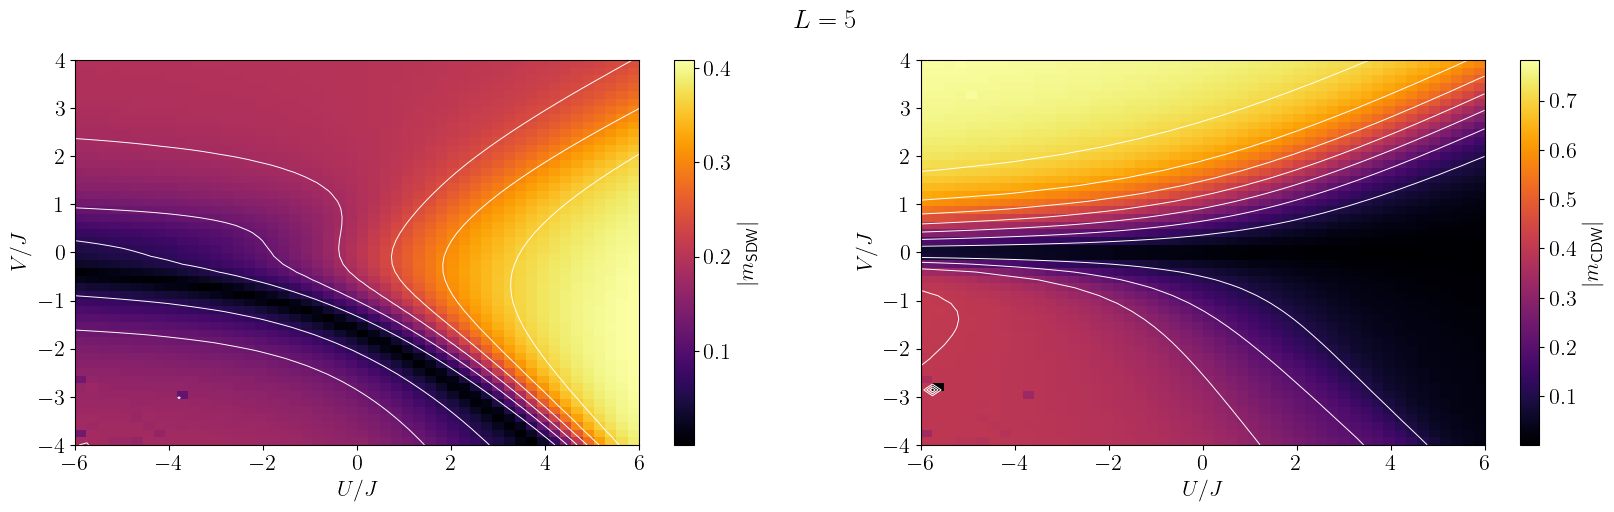

In [ ]:
m_sdw = np.zeros((N_Points, N_Points))
m_cdw = np.zeros((N_Points, N_Points))

for i, U in enumerate(U_vals):
    for j, V in enumerate(V_vals):

        magnetization_ij = magnetization[i, j]
        charge_density_ij = charge_density[i, j]

        m_sdw[i, j] = np.abs(m_SDW(L, magnetization_ij))
        m_cdw[i, j] = np.abs(m_CDW(L, charge_density_ij))

# The data in m_sdw and m_cdw are transposed!
m_sdw = m_sdw.T 
m_cdw = m_cdw.T

# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(20, 5), sharex=True)
plt.suptitle(f"$L = {L}$")

# Plot m_SDW heatmap
im0 = ax[0].imshow(m_sdw, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap="inferno")
fig.colorbar(im0, ax=ax[0], label=r"$|m_{\text{SDW}}|$")

X, Y = np.meshgrid(U_vals, V_vals)
ax[0].contour(X, Y, m_sdw, colors='white', linestyle='--', linewidths=0.7)

ax[0].set_xlabel(r"$U / J$")
ax[0].set_ylabel(r"$V / J$")
#ax[0].set_title(r"$m_{\text{SDW}}=(1/L) \sum_{j}(-1)^j \langle \hat{S}_{j}^{z} \rangle$")

# Plot m_CDW heatmap
im1 = ax[1].imshow(m_cdw, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap="inferno")
fig.colorbar(im1, ax=ax[1] , label=r"$|m_{\text{CDW}}|$")

X, Y = np.meshgrid(U_vals, V_vals)
ax[1].contour(X, Y, m_cdw, colors='white', linestyle='--', linewidths=0.7)

ax[1].set_xlabel(r"$U / J$")
ax[1].set_ylabel(r"$V / J$")

#ax[1].set_title(r"$m_{\text{CDW}}=(1/L)\sum_{j}(-1)^j (\langle \hat{n}_j \rangle-1)$")

# Plot line U = 2V
# V_range = np.linspace(0, U_max / 2, N_Points)
# U_range = 2 * V_range 
# ax[0].plot(U_range, V_range, 'w--', linewidth=1)
# ax[1].plot(U_range, V_range, 'w--', linewidth=1)

# Save the figure
plt.savefig(f"{figures_path}/{model}_{exec}/order_parameters_L={L}_Npoints={N_Points}_Umax={U_max}_Vmax={V_max}.png", dpi=300, bbox_inches="tight")
plt.show()

- Energy


/tmp/ipykernel_84538/2413442496.py:11: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ax.contour(X, Y, E_GS, colors='white', linestyle='--', linewidths=0.7)


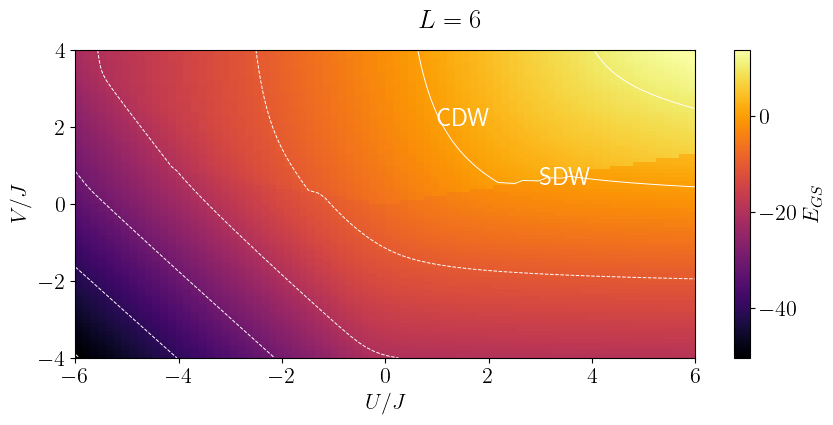

In [63]:
# _, _, _, energy, _, _, _, U_vals, V_vals = load_data(L, U_max, V_max, N_Points)
# Create a figure with two subplots
fig, ax = plt.subplots(1, 1, figsize=(10, 4), sharex=True)
    
im0 = ax.imshow(E_GS, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap="inferno")
fig.colorbar(im0, ax=ax, label=r"$E_{GS}$")
ax.set_xlabel(r"$U / J$")
ax.set_ylabel(r"$V / J$")

X, Y = np.meshgrid(U_vals, V_vals)
ax.contour(X, Y, E_GS, colors='white', linestyle='--', linewidths=0.7)

# Plot line U = 2V
# V_range = np.linspace(0, U_max / 2, N_Points)
# U_range = 2 * V_range 
# ax.plot(U_range, V_range, 'w--', linewidth=1)  
    
ax.text(1, 2, "$\\text{CDW}$", color = "white", fontsize=18)
ax.text(3, 0.5, "$\\text{SDW}$", color = "white", fontsize=18)
    
plt.suptitle(f"$L = {L}$")
plt.show()
fig.savefig(f"{figures_path}/{model}_{exec}/E_GS={L}_{model}_NPoints={N_Points}.png", dpi = 500, bbox_inches='tight')

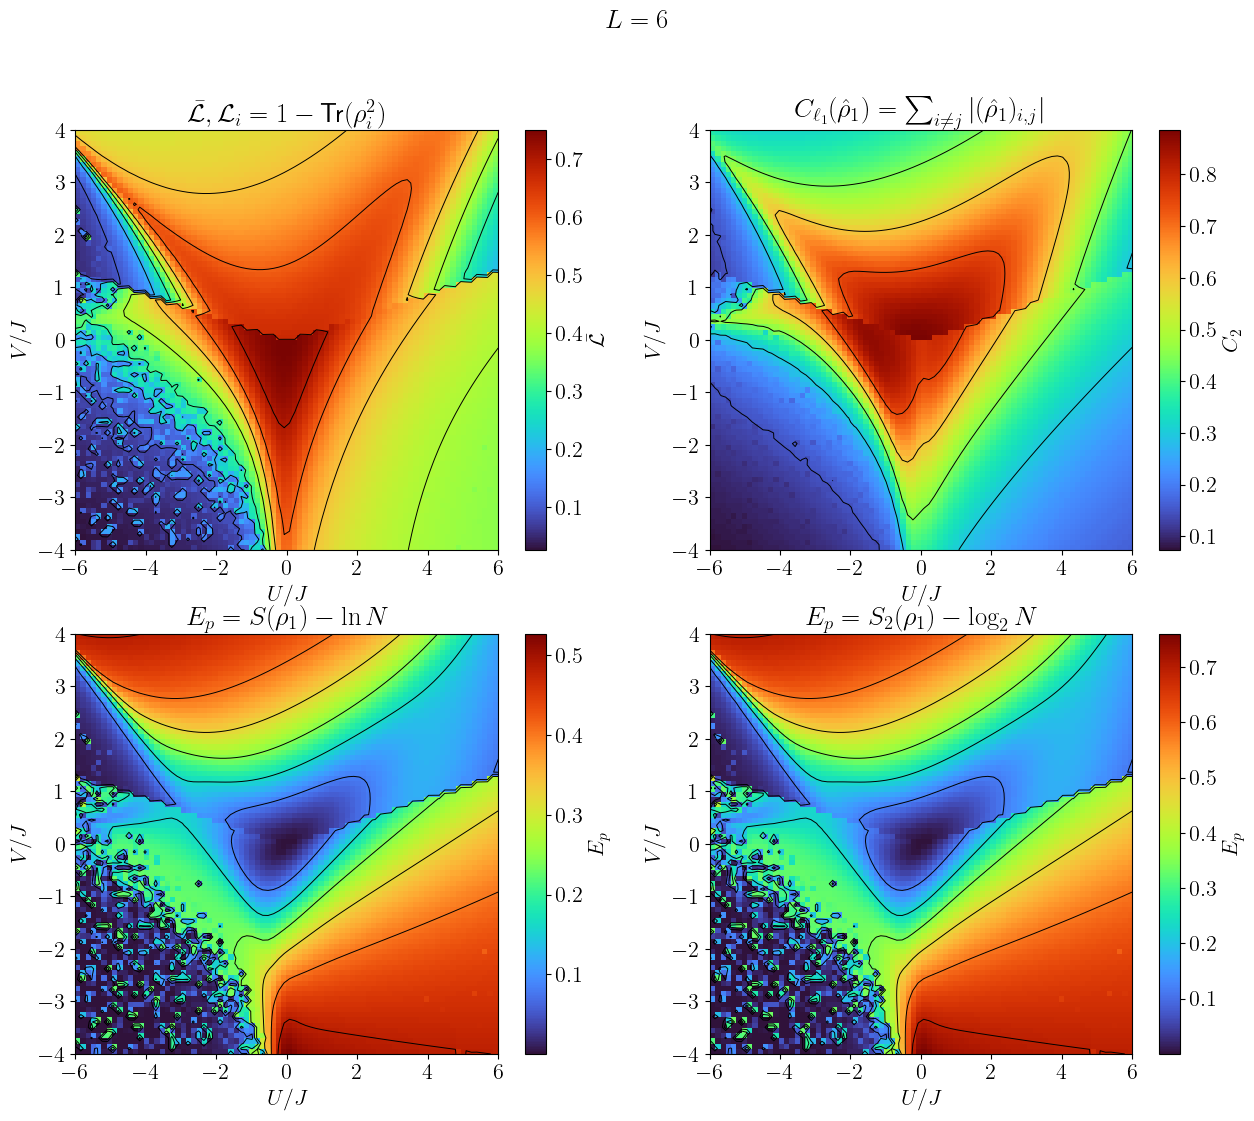

In [61]:

# Create a figure with two subplots
fig, ax1 = plt.subplots(2, 2, figsize=(15, 12))
plt.suptitle(f"$L = {L}$")

# Shared colorbar normalization - thanks chatgpt
# vmin = min(np.min(avg_linear_entropy), np.min(E_p))
# vmax = max(np.max(avg_linear_entropy), np.max(E_p))

U_min = np.min(U_vals)
U_max = np.max(U_vals)
V_min = np.min(V_vals)
V_max = np.max(V_max)

# E_p = E_p / np.max(E_p) 
# avg_linear_entropy = avg_linear_entropy / np.max(avg_linear_entropy)

# Contour 
X, Y = np.meshgrid(U_vals, V_vals)

im0 = ax1[0, 0].imshow(avg_linear_entropy, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap="turbo")# , vmin=vmin, vmax=vmax)
fig.colorbar(im0, ax = ax1[0, 0], orientation='vertical', label=r"$\bar{\mathcal{L}}$") # /\text{max}(\bar{\mathcal{L}})$")

ax1[0, 0].contour(X, Y, avg_linear_entropy, colors='black', linewidths=0.7)

im2 = ax1[0, 1].imshow(quantum_coherence, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap="turbo") #  , vmin=vmin, vmax=vmax)
fig.colorbar(im2, ax = ax1[0, 1], orientation='vertical',  label=r"$C_2$")
ax1[0, 1].contour(X, Y, quantum_coherence, colors='black', linewidths=0.7)

im1 = ax1[1, 0].imshow(E_p, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap="turbo") #  , vmin=vmin, vmax=vmax)
fig.colorbar(im1, ax = ax1[1, 0], orientation='vertical',  label=r"$E_p$") #  / \text{max}(E_{p})$")
ax1[1, 0].contour(X, Y, E_p, colors='black', linewidths=0.7)


im1 = ax1[1, 1].imshow(E_p_bits, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap="turbo") #  , vmin=vmin, vmax=vmax)
fig.colorbar(im1, ax = ax1[1, 1], orientation='vertical',  label=r"$E_p$") #  / \text{max}(E_{p})$")
ax1[1, 1].contour(X, Y, E_p, colors='black', linewidths=0.7)

# bar = plt.colorbar(im0, orientation='vertical', shrink=0.8, label=r"$E_p$") 
ax1[0, 0].set_xlabel(r"$U / J$")
ax1[0, 0].set_ylabel(r"$V / J$")

ax1[1, 0].set_xlabel(r"$U / J$")
ax1[1, 0].set_ylabel(r"$V / J$")

ax1[0, 1].set_xlabel(r"$U / J$")
ax1[0, 1].set_ylabel(r"$V / J$")

ax1[1, 1].set_xlabel(r"$U / J$")
ax1[1, 1].set_ylabel(r"$V / J$")

ax1[0, 0].set_title(r"$\bar{\mathcal{L}}, \mathcal{L}_i = 1 - \text{Tr}(\rho_i^2)$")
ax1[0, 1].set_title(r"$C_{\ell_1}(\hat{\rho}_1) = \sum_{i\neq j}|(\hat{\rho}_1)_{i, j}|$")
ax1[1, 0].set_title(r"$E_p = S(\rho_1) - \ln N$")
ax1[1, 1].set_title(r"$E_p = S_2(\rho_1) - \log_2 N$")

# ax1[0].hlines(0, 0, -6.0, colors="white", linestyles='solid')
# ax1[1].hlines(0, 0, -6.0, colors="white", linestyles='solid')
## Plot line U = 2V
# V_range = np.linspace(0, U_max / 2, N_Points)
# U_range = 2 * V_range 
# ax1[0].plot(U_range, V_range, 'w', linewidth=1)
# ax1[1].plot(U_range, V_range, 'w', linewidth=1)
# ax1[0].plot(U_range, -V_range, 'w', linewidth=1)
# ax1[1].plot(U_range, -V_range, 'w', linewidth=1)
# ax1[2].plot(U_range, -V_range, 'w', linewidth=1# )
# ax1[0].text(-4, 2, "CDW random_MPS", fontweight='bold', color = "white", fontsize=18)
# ax1[0].text(2, 0, "SDW random_MPS", fontweight='bold', color = "white", fontsize=18)
# ax1[1].text(-4, 2, "CDW random_MPS", fontweight='bold', color = "white", fontsize=18)
# ax1[1].text(2, 0, "SDW random_MPS", fontweight='bold', color = "white", fontsize=18)

fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_entropy_1_RDM_L={L}_NPoints={N_Points}.png", dpi=100, bbox_inches='tight')
plt.show()

Tests